# Lab 7: The Verification Lab

**DSA 405 · Week 7**

| | |
|---|---|
| **In class** | Friday, Oct 2 |
| **A7 due** | Thursday, Oct 8, 11:59 PM |
| **Files** | `inspections_a.csv`, `inspections_b.csv`, `DSA405_Wk07_broken_pipeline.ipynb` |
| **Time** | ~25 min in class, ~60 min at home |

## Overview

A language model can write data-wrangling code in about thirty seconds, and the code
usually looks fine. Checking whether the numbers that come out of it are correct takes
much longer, and that checking is your job. This week we learn two tools for it:
`groupby`, which computes a summary (like a mean or a count) for each group of rows,
and `assert`, which lets you write a statement you believe about the data so that
Python re-checks it every time the notebook runs.

The take-home is an audit: you will read a notebook someone else produced and check
whether its answers are correct. We gave a language model these two inspection files,
asked for a county report, and got back a notebook that runs top to bottom without a
single error message. Three of its answers are wrong. It will be your job to identify the problemns.

In [1]:
# ---------------------------------------------------------------------------
# DSA 405 setup
# ---------------------------------------------------------------------------
import pandas as pd, numpy as np, requests, io

# Where the class data files live. Swap in the local path if you're not on Colab.
DATA = "https://raw.githubusercontent.com/jon-holt/DSA-405-Student/main/datasets/"
# DATA = "data/raw/"          # local users


def load(filename, kind="csv", **kw):
    """Read a class file whether DATA is a URL or a local folder."""
    # Glue the folder/URL in DATA onto the file name you asked for.
    path = DATA + filename
    # Each branch picks the reader that matches the file type.
    if kind == "csv":
        return pd.read_csv(path, **kw)
    if kind == "excel":
        return pd.read_excel(path, **kw)
    if kind == "text":
        # Plain text comes over the network with requests, or off disk with open().
        return requests.get(path, timeout=30).text if path.startswith("http") else open(path).read()
    if kind == "json":
        if path.startswith("http"):
            return requests.get(path, timeout=30).json()
        import json as _j
        return _j.load(open(path))
    # Stop with a clear message if someone asks for a file type we don't handle.
    raise ValueError(kind)


# Give pandas more horizontal room so wide tables don't wrap.
pd.set_option("display.width", 160)
print("pandas", pd.__version__)


pandas 3.0.5


---
# Part 1: Explore (in class)

## Task 1.1: Split, apply, combine

We'll build the clean merge from last week (grain, join, assert), then compute some
summaries from it:

In [2]:
# One row per inspection.
insp = load("inspections_a.csv")
# One row per restaurant: drop_duplicates keeps the first row for each restaurant_id.
rest = load("inspections_b.csv").drop_duplicates("restaurant_id")

# Attach restaurant details to each inspection; validate="many_to_one" makes pandas
# raise an error if rest somehow still has repeated restaurant_ids.
df = insp.merge(rest, on="restaurant_id", how="left", validate="many_to_one")
# The merge should not add or lose rows, so the count must still match insp.
assert len(df) == 1200, f"expected 1200 rows, got {len(df)}"

# Split rows by city, compute the mean score and the number of inspections for each,
# round to one decimal, and sort from worst mean score to best.
by_city = df.groupby("city").score.agg(["mean", "count"]).round(1).sort_values("mean")
print(by_city)


               mean  count
city                      
Garner         88.5    114
Fuquay-Varina  89.5     96
Knightdale     91.1    127
Morrisville    92.3    103
Raleigh        92.3    158
Durham         92.5     98
Wake Forest    92.6    137
Holly Springs  92.7    156
Apex           94.3    115
Cary           95.5     96


`groupby` works in three steps, called split-apply-combine: split the rows into groups
by city, apply `mean` and `count` to each group, and combine the results into one
table. Notice that the code computes `count` alongside `mean`. Make that a habit: you
should trust a mean computed from 12 rows less than a mean computed from 200 rows, and
the count is the only number on screen that tells you which one you are looking at.

Next, we check whether score is related to violations:

In [3]:
# Correlation: a number from -1 to 1 saying how strongly the two columns move together.
r = df.score.corr(df.critical_violations)
print(f"corr(score, critical_violations) = {r:.3f}")


corr(score, critical_violations) = -0.721


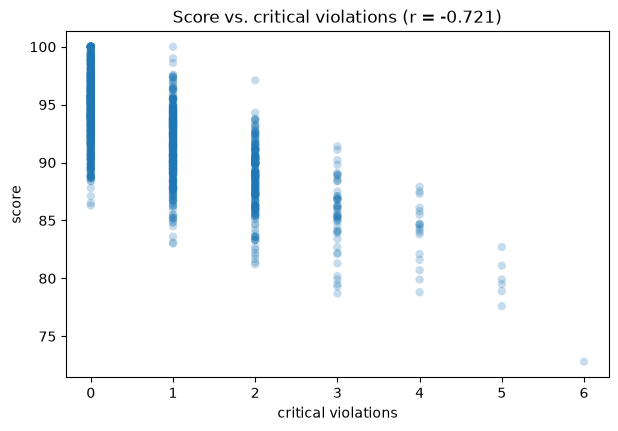

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
# alpha makes overlapping points semi-transparent, so dark spots mean many inspections landed there.
ax.scatter(df.critical_violations, df.score, alpha=0.25, edgecolor="none")
ax.set_xlabel("critical violations")
ax.set_ylabel("score")
ax.set_title(f"Score vs. critical violations (r = {r:.3f})")
plt.show()


The correlation is strongly negative: more critical violations go together with lower
scores. That is the direction we would expect if both columns contain what their names
say they contain.

## Task 1.2: Writing your assumptions down as code

You've been running small checks since Lab 2. Here we collect them into something
reusable.

Any time you notice yourself thinking "there should be one row per
inspection" or "scores can't go above 100", you have made an assumption about the data.
If you write the assumption in a comment, nothing checks it, and the data can change
without you noticing. If you write it in an `assert`, Python checks it on every run and
shows an error message as soon as the assumption stops being true.

In [5]:
# Each assert says "this must be true"; if it isn't, Python stops and prints the message.
assert len(df) == 1200,                       "row count changed"
assert df.inspection_id.is_unique,            "duplicate inspections"
assert df.score.between(0, 100).all(),       "impossible score"
assert df.restaurant_name.notna().all(),      "an inspection lost its restaurant"
assert (df.critical_violations >= 0).all(),   "negative violation count"
print("all five assumptions hold")


all five assumptions hold


Those five lines take about a millisecond to run, so there is no reason to limit how
many you write. Compare that with scrolling through `.head()`, which shows you five
rows, once, and only the five rows that happen to be at the top.

## Task 1.3: A mistake worth making once, on purpose

`reinspection_required` looks like it contains `True` and `False`. It does not, but it contains something very similar. Compute the
reinspection *rate*:

In [6]:
# Peek at the first three values to see what this column actually holds.
print(df.reinspection_required.head(3).tolist())
print()
# == "Y" turns the column into True/False, and the mean of True/False is the share of True.
rate = (df.reinspection_required == "Y").mean()
print(f"reinspection rate: {rate:.1%}")


['N', 'N', 'N']

reinspection rate: 23.2%


The column contains the strings `"Y"` and `"N"`. If you call `.mean()` on it directly,
Python raises an error. The error is annoying, but it is also useful, because you find
out right away that something is wrong. 

The problem is that `True` and `False` are special terms in Python, and they represent something meaningful. By default, Python understands `True` and `False` but not `"Y"` and `"N"`. Therefore, if we want to compute statistics about `"Y"` and `"N"`, we need to be explicit, like the cell above. On the contrary, if the data were represented as `True` and `False`, we could simply use `mean()` without the `==` sign. 

One assertion catches this whole family of problems:
`assert set(df.reinspection_required) <= {"Y", "N"}`. It means: every value in this
column must be `"Y"` or `"N"`. If the column ever contains anything else, including
actual `True`/`False` values, the assert will fail and show you an error message.

---
## Checkpoint: submit before leaving class

1. Which city has the worst mean score, and how many inspections is that mean based on?
2. Pick one of the five assertions from Task 1.2 and describe a realistic mistake in an
   earlier step of the pipeline that it would catch.
3. What does `(df.reinspection_required == True).mean()` return, and why is that worse
   than an error?

*Answers here.*

---
# Part 2: A6 (Aggregation & Verification)

Three tasks, and they make up the take-home half of the week.

## Task 2.1: One question, with a confidence statement

Choose one question about the clean 1,200-row table that needs a `groupby` to answer:
by city, by month, by inspector, or another grouping you're curious about. Report the
answer **with group sizes**, and include a sentence that interprets your results. What did you learn?

In [7]:
# your analysis

*Finding and confidence statement here.*

## Task 2.2: Audit the pipeline

Open `DSA405_Wk07_broken_pipeline.ipynb`, posted alongside this lab. A language model
wrote it from a one-line prompt asking for a county-wide report on these two files. The
notebook runs from top to bottom with no error message, prints tables that look
correct, and gets three things wrong.

1. Run it start to finish and confirm that no cell raises an error.
2. Find as many of the three problems as you can. For each one, tell me which cell it
   is in, what the code does compared with what it should do, and why Python raised no
   error.
3. Write the `assert` that would have caught it.

Most people find one of the three problems on a first try; finding two usually takes considerable effort. If you find all three, you should drop out of school and get a job at SpaceX (just kidding).

In [ ]:
# your audit notes and assertions

*The three (or fewer, honestly reported) findings.*

## Task 2.3: A verification suite, and its gap

Now write a reusable **verification suite** for the inspections data: a group of
`assert` statements that you run together to check the data. Write **at least six
assertions**, each checking a value you computed and believe is correct (row count, key
uniqueness, value ranges, rate bounds, category domains; the Task 1.3 string problem
may be one of them).

Then show that the suite can actually catch an error. Re-create the naive 5,800-row
merge on purpose (the same fan-out merge we saw in Week 6), run your assertions on the result, and show which ones fail. Until
you have watched the suite catch a real error, you do not know whether it can.

Finally, write a paragraph describing **one realistic change to this data that
your suite would not catch.** This is a key skill for professional data scientists: anticipating gaps where your current workflow can fall short. 

In [ ]:
# your verification code goes here

*Honesty paragraph here.*

---
## AI use note

Tell me which AI tools you used here and what you used them for, in a sentence or two.
If you didn't use any, write "none."

*Answer here.*

---
## Submitting

1. **Runtime > Restart runtime**, then **Run all**.
2. `File > Download > Download .ipynb`
3. Rename to `DSA405_002_FA26_A6_[yourUnityID].ipynb`
4. Upload to the **A6** space on Moodle.

The **Checkpoint** section goes separately to **Week 7 In-Class Activity** before the
end of class on Friday. A6 is due **Thursday, Oct 8, 11:59 PM**.